# Exploratory Data Analysis (EDA) - Solar Energy & Weather Analytics

This notebook conducts exploratory data analysis on historical solar generation, energy consumption, and weather variables to understand distributions, correlations, and temporal patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

/var/folders/lh/gvpbf1b15yd43l_x_kk3zxgc0000gn/T/ipykernel_22063/175743962.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Data Loading & Inspection

In [2]:
solar_d = pd.read_csv('../data/fact_solar_daily.csv', parse_dates=['date'])
solar_h = pd.read_csv('../data/fact_solar_hourly.csv', parse_dates=['date', 'hour_ts'])
weather_d = pd.read_csv('../data/fact_weather_daily.csv', parse_dates=['date'])
weather_h = pd.read_csv('../data/fact_weather_hourly.csv', parse_dates=['date', 'hour_ts'])
dim_date = pd.read_csv('../data/dim_date.csv', parse_dates=['date'])
wc_codes = pd.read_csv('../data/dim_weather_codes.csv')

# Merge daily data
daily = pd.merge(solar_d, weather_d, on='date', how='inner')
daily = pd.merge(daily, dim_date[['date', 'month_name', 'season', 'is_weekend', 'day_name']], on='date', how='left')

print('Daily records:', len(daily))
print('Hourly solar records:', len(solar_h))
print('Date range:', daily['date'].min().strftime('%Y-%m-%d'), 'to', daily['date'].max().strftime('%Y-%m-%d'))
daily.head()

Daily records: 89
Hourly solar records: 2135
Date range: 2026-02-01 to 2026-05-01


,date,generation_kwh,consumption_kwh,grid_feed_in_kwh,grid_purchase_kwh,charge_kwh,discharge_kwh,shortwave_radiation_sum,sunshine_duration,daylight_duration,cloud_cover_mean,temperature_2m_mean,relative_humidity_2m_mean,rain_sum,wind_speed_10m_mean,weather_code,month_name,season,is_weekend,day_name
0,2026-02-01,0.644000,6.366083,0.009500,0.006583,0.090667,6.213917,20.299999,39596.742188,41521.167969,85.583336,25.579170,63.604191,0.0,19.997684,3,NaN,NaN,NaN,NaN
1,2026-02-02,23.846583,23.460333,0.092583,0.028250,14.104750,14.324167,21.360001,40360.882812,41559.683594,31.791666,25.539581,61.137543,0.0,19.370516,3,February,Dry,False,Monday
2,2026-02-03,26.952417,23.071500,0.115000,0.074000,16.495917,13.070250,20.670000,40128.117188,41598.648438,22.750000,24.775000,72.427101,0.2,18.443417,51,February,Dry,False,Tuesday
3,2026-02-04,25.966000,25.731917,0.053250,0.030333,14.770833,15.051417,20.910000,39399.308594,41638.011719,92.541664,25.089584,69.790871,0.0,14.603719,3,February,Dry,False,Wednesday
4,2026-02-05,27.200417,23.586667,0.097917,0.030083,16.668250,13.444250,14.670000,25119.896484,41677.734375,100.000000,24.693747,74.526039,8.1,13.445566,61,February,Dry,False,Thursday


## 2. Missing Values Analysis

In [3]:
missing = daily.isnull().sum()
missing_pct = (missing / len(daily)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct.round(2)})
print('Missing values summary:')
print(missing_df[missing_df['Missing Count'] > 0])

Missing values summary:
                   Missing Count  Percentage (%)
grid_purchase_kwh              1            1.12
month_name                     1            1.12
season                         1            1.12
is_weekend                     1            1.12
day_name                       1            1.12


## 3. Variable Distributions

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
vars_to_plot = [
    ('generation_kwh', 'Solar Generation (kWh)', 'skyblue'),
    ('consumption_kwh', 'Consumption (kWh)', 'salmon'),
    ('shortwave_radiation_sum', 'Shortwave Radiation (W/m²)', 'gold'),
    ('sunshine_duration', 'Sunshine Duration (s)', 'orange'),
    ('cloud_cover_mean', 'Cloud Cover (%)', 'lightgray'),
    ('temperature_2m_mean', 'Temperature (°C)', 'lightgreen')
]

for ax, (col, title, color) in zip(axes.flatten(), vars_to_plot):
    sns.histplot(daily[col].dropna(), kde=True, ax=ax, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

<Figure size 1500x900 with 6 Axes>

## 4. Solar Generation vs Key Drivers (Radiation & Cloud Cover)

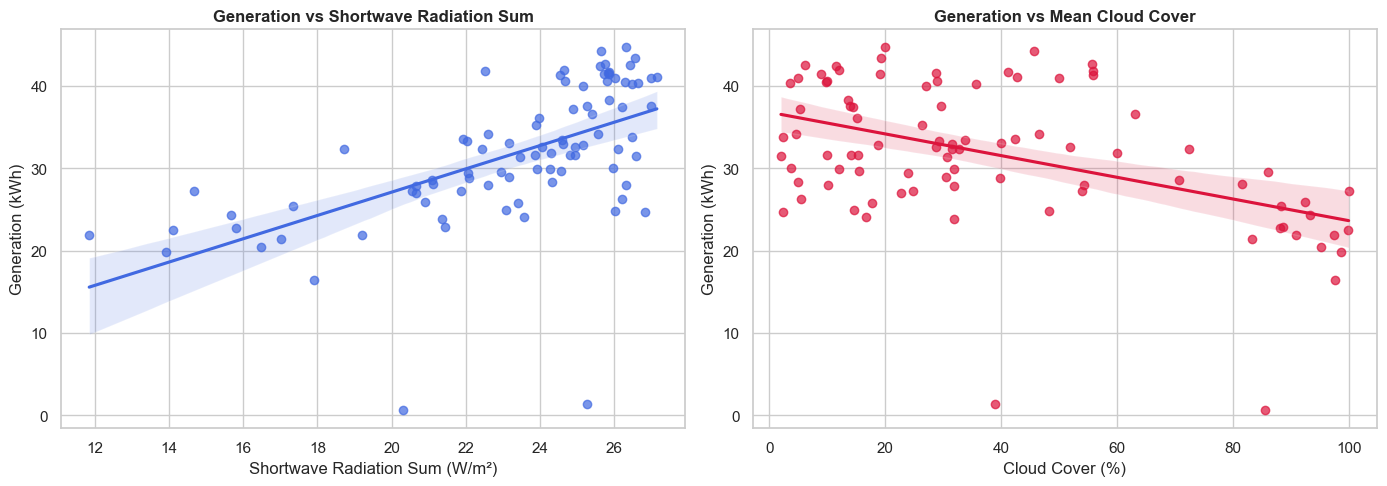

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Generation vs Shortwave Radiation
sns.regplot(data=daily, x='shortwave_radiation_sum', y='generation_kwh', ax=axes[0],
            color='royalblue', scatter_kws={'alpha': 0.7})
axes[0].set_title('Generation vs Shortwave Radiation Sum', fontweight='bold')
axes[0].set_xlabel('Shortwave Radiation Sum (W/m²)')
axes[0].set_ylabel('Generation (kWh)')

# Generation vs Cloud Cover
sns.regplot(data=daily, x='cloud_cover_mean', y='generation_kwh', ax=axes[1],
            color='crimson', scatter_kws={'alpha': 0.7})
axes[1].set_title('Generation vs Mean Cloud Cover', fontweight='bold')
axes[1].set_xlabel('Cloud Cover (%)')
axes[1].set_ylabel('Generation (kWh)')

plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

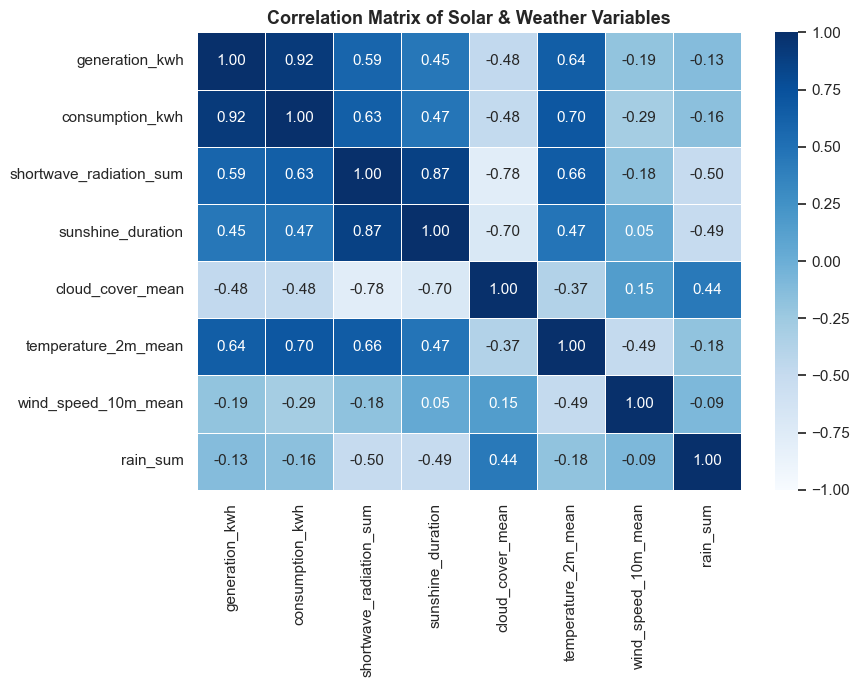

In [6]:
corr_cols = [
    'generation_kwh', 'consumption_kwh', 'shortwave_radiation_sum',
    'sunshine_duration', 'cloud_cover_mean', 'temperature_2m_mean',
    'wind_speed_10m_mean', 'rain_sum'
]
corr_matrix = daily[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Solar & Weather Variables', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Temporal, Seasonal & Day-of-Week Patterns

/var/folders/lh/gvpbf1b15yd43l_x_kk3zxgc0000gn/T/ipykernel_22063/695513391.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily.dropna(subset=['day_name']), x='day_name', y='generation_kwh', order=day_order, ax=axes[1], palette='Blues')


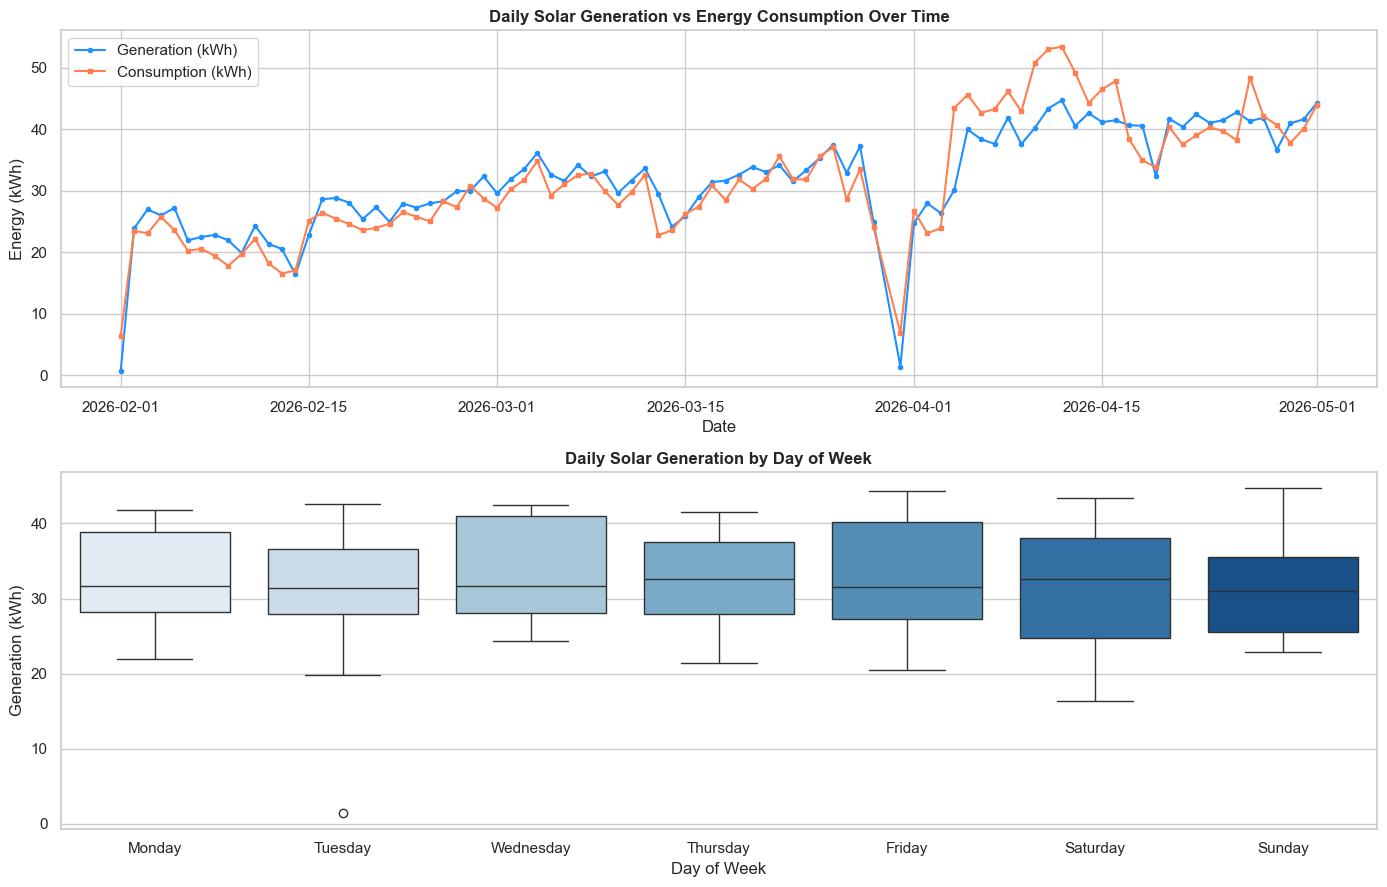

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

daily_sorted = daily.sort_values('date')
axes[0].plot(daily_sorted['date'], daily_sorted['generation_kwh'], label='Generation (kWh)', marker='o', markersize=3, color='dodgerblue')
axes[0].plot(daily_sorted['date'], daily_sorted['consumption_kwh'], label='Consumption (kWh)', marker='s', markersize=3, color='coral')
axes[0].set_title('Daily Solar Generation vs Energy Consumption Over Time', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Energy (kWh)')
axes[0].legend()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=daily.dropna(subset=['day_name']), x='day_name', y='generation_kwh', order=day_order, ax=axes[1], palette='Blues')
axes[1].set_title('Daily Solar Generation by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Generation (kWh)')

plt.tight_layout()
plt.show()

## 7. Hourly Generation Patterns

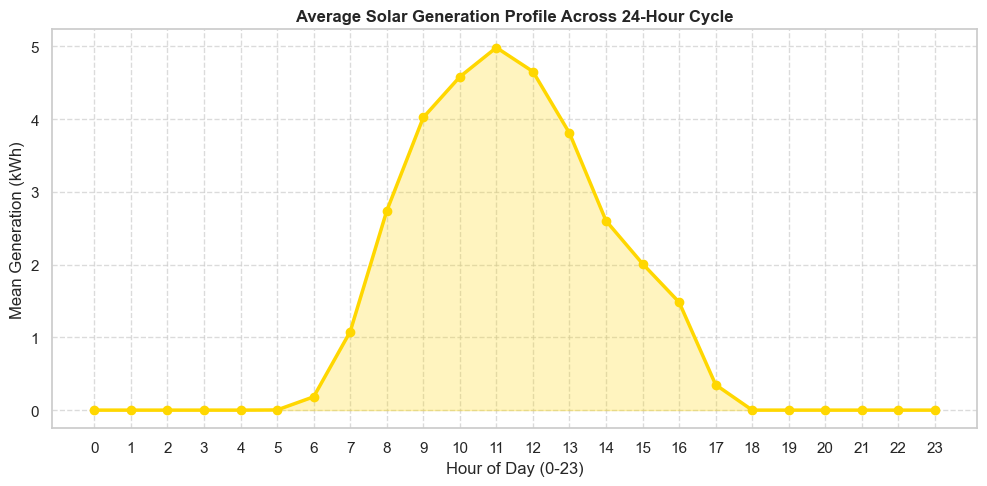

In [8]:
hourly_avg = solar_h.groupby(solar_h['hour_ts'].dt.hour)['generation_kwh'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg['hour_ts'], hourly_avg['generation_kwh'], marker='o', color='gold', linewidth=2.5, markersize=6)
plt.fill_between(hourly_avg['hour_ts'], hourly_avg['generation_kwh'], alpha=0.25, color='gold')
plt.title('Average Solar Generation Profile Across 24-Hour Cycle', fontweight='bold')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Mean Generation (kWh)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 8. Summary of EDA Insights
- **Radiation is the Primary Driver**: Shortwave radiation shows the strongest positive correlation with daily solar generation.
- **Cloud Cover Impact**: Cloud cover has a pronounced negative correlation with generation, dampening peak daily yields.
- **Diurnal Cycle**: Solar generation follows a standard bell curve, ramping up from 06:00, peaking between 11:00 and 13:00, and tapering off by 18:00.
- **Weekday Independence**: Solar generation does not vary systematically by day of the week, as it depends purely on atmospheric conditions.